In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

In [16]:
iris = datasets.load_iris()
X = iris.data[:, :2]
y = (iris.target != 0) * 1

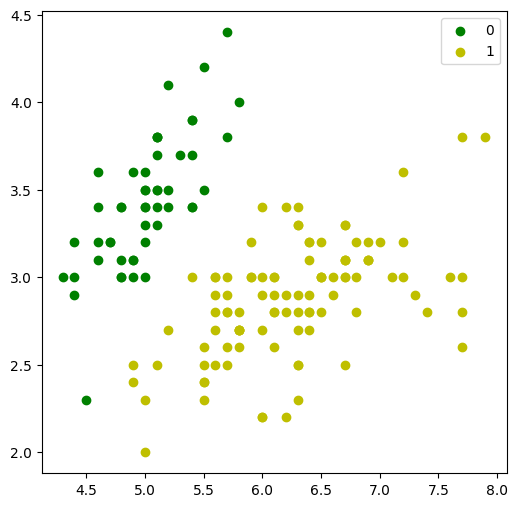

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='g', label='0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='y', label='1')
plt.legend()

In [18]:
class LogisticRegression:
   def __init__(self, lr=0.01, num_iter=100000, fit_intercept=True, verbose=False):
      self.lr = lr
      self.num_iter = num_iter
      self.fit_intercept = fit_intercept
      self.verbose = verbose
   def __add_intercept(self, X):
      intercept = np.ones((X.shape[0], 1))
      return np.concatenate((intercept, X), axis=1)
   def __sigmoid(self, z):
      return 1 / (1 + np.exp(-z))
   def __loss(self, h, y):
      return (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()
   def fit(self, X, y):
      if self.fit_intercept:
         X = self.__add_intercept(X)

In [19]:
import numpy as np

class LogisticRegression:
    def __init__(self, lr=0.01, num_iter=10000, verbose=False):
        self.lr = lr
        self.num_iter = num_iter
        self.verbose = verbose
        self.theta = None

    def __sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def __loss(self, h, y):
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)
        return (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()

    def fit(self, X, y):
        self.theta = np.zeros(X.shape[1])   # ✅ Now self is defined

        for i in range(self.num_iter):
            z = np.dot(X, self.theta)
            h = self.__sigmoid(z)
            gradient = np.dot(X.T, (h - y)) / y.size
            self.theta -= self.lr * gradient

            if self.verbose and i % 1000 == 0:
                loss = self.__loss(h, y)
                print(f"Iteration {i} - Loss: {loss:.6f}")

    def predict_prob(self, X):
        return self.__sigmoid(np.dot(X, self.theta))

    def predict(self, X, threshold=0.5):
        return self.predict_prob(X) >= threshold


In [20]:
def predict_prob(self, X):
   if self.fit_intercept:
      X = self.__add_intercept(X)
   return self.__sigmoid(np.dot(X, self.theta))
def predict(self, X):
   return self.predict_prob(X).round()

In [21]:
model = LogisticRegression(lr=0.1, num_iter=300000)
preds = model.predict(X)
(preds == y).mean()

plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='g', label='0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='y', label='1')
plt.legend()
x1_min, x1_max = X[:,0].min(), X[:,0].max(),
x2_min, x2_max = X[:,1].min(), X[:,1].max(),
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max), np.linspace(x2_min, x2_max))
grid = np.c_[xx1.ravel(), xx2.ravel()]
probs = model.predict_prob(grid).reshape(xx1.shape)
plt.contour(xx1, xx2, probs, [0.5], linewidths=1, colors='red');

TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'